# Dataset Characterization

the idea of this notebook is to characterize the dataset only, regarding only structures dft data, maybe composition , ternary plot, and this kind of things.

input: `CuratedBriefSummary.pkl` 

output: plots

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from itertools import permutations
import seaborn as sns
plt.style.use('default')
plt.rc('figure', figsize = (10,8))
plt.rc('text',usetex=True)
plt.rc('font', size=24)
dataset = 'Cr-Co-W'#'Fe-Mo/'


In [2]:
BSfile = os.path.join(dataset,'CuratedParsedBriefSummary.pkl' )
BS = pd.read_pickle(BSfile)

# Compositions 

# Population of phases

<AxesSubplot:xlabel='Phase', ylabel='Count'>

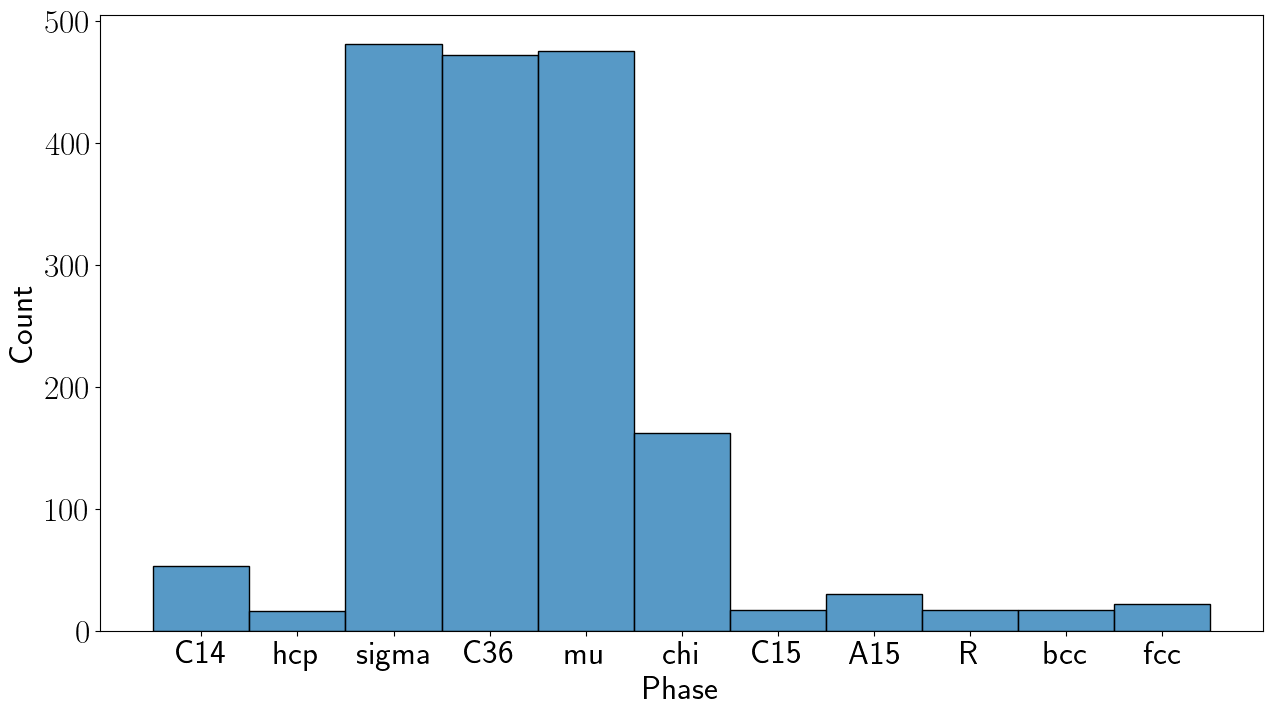

In [3]:
fig, ax = plt.subplots(figsize=(15,8))
sns.histplot(x = BS['Phase'], ax=ax)

#  Obvious outliers removal

In [4]:
BS = BS[(BS.B0 > 0 ) ]

# Distribution of Target Variables 

## total energy

In [5]:
targets = {'E0':r'$E_0$', 'B0':r'$B_0$', 'V0':r'$V_0$'}

some obvious outliers:

In [15]:
if dataset == 'Cr-Co-W':
    BS = BS[(BS['E0']>-500) & (BS['V0']<40)]

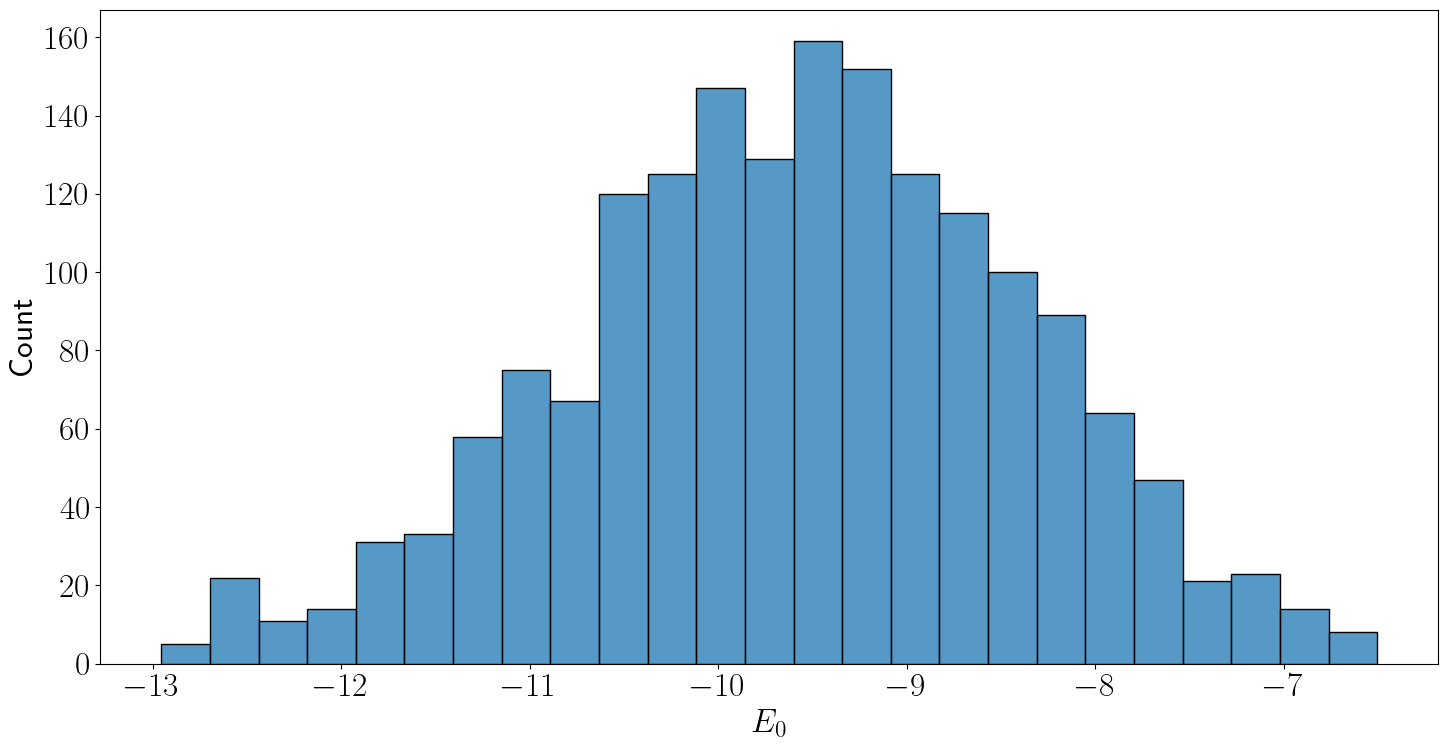

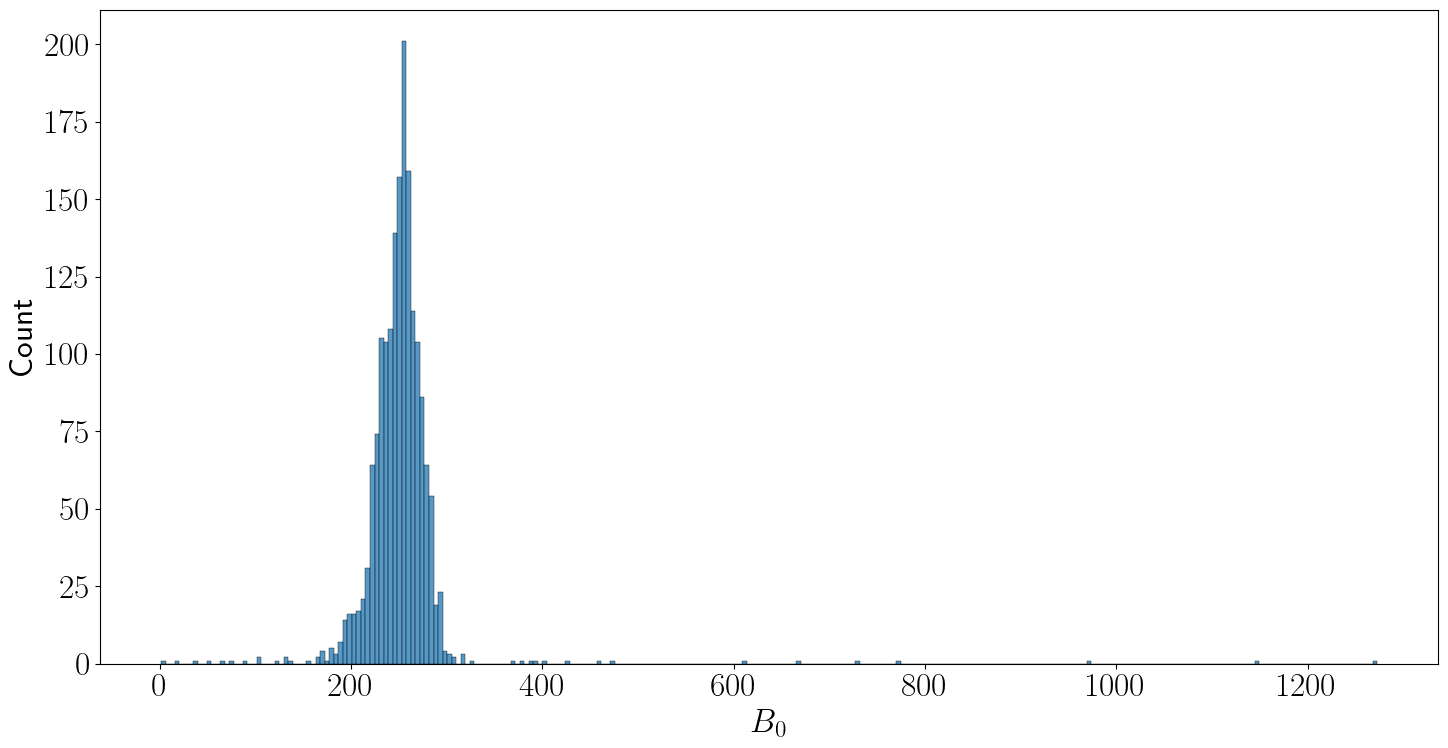

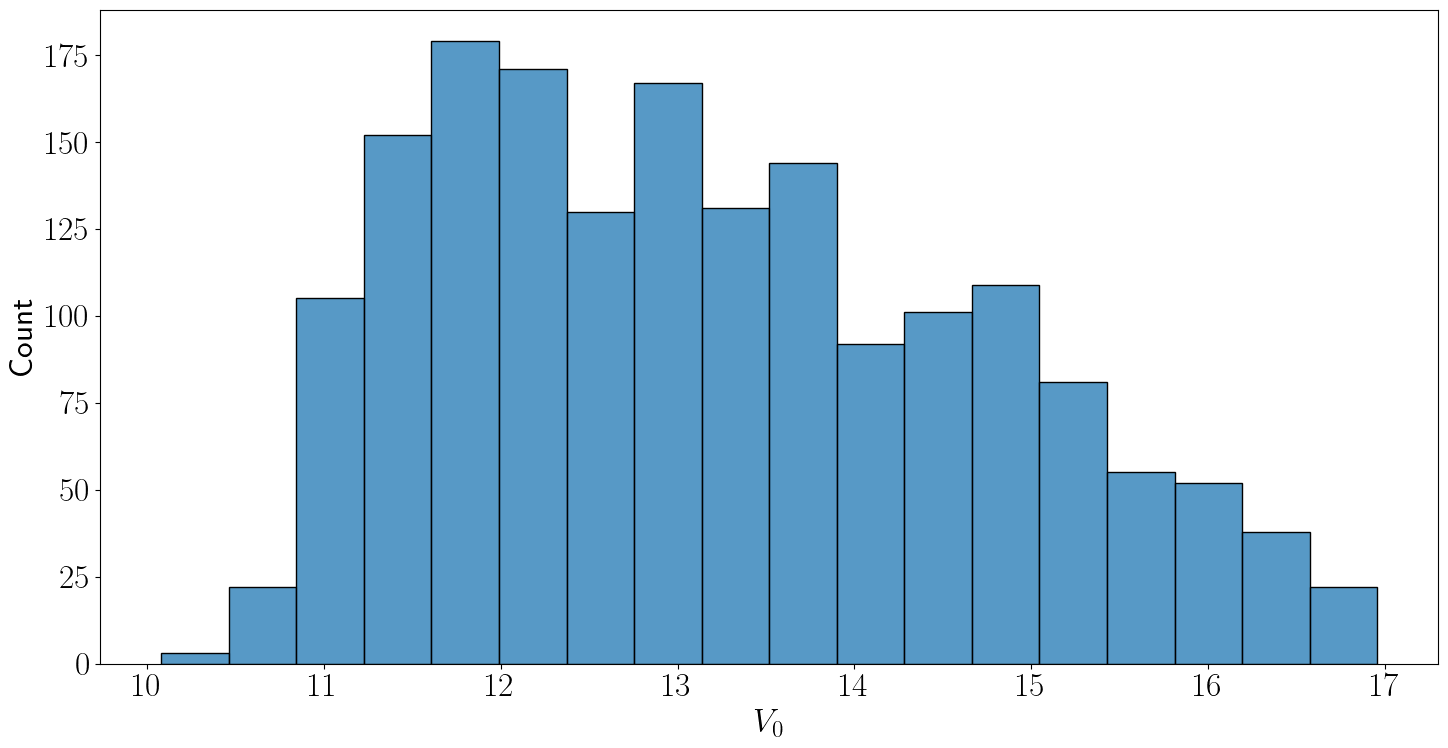

In [16]:
for target, label in targets.items():
    fig, ax = plt.subplots(figsize = (15,8 ))
    sns.histplot(x = BS[target], ax = ax)
    ax.set_xlabel(label)
    fig.tight_layout()

# General correlation

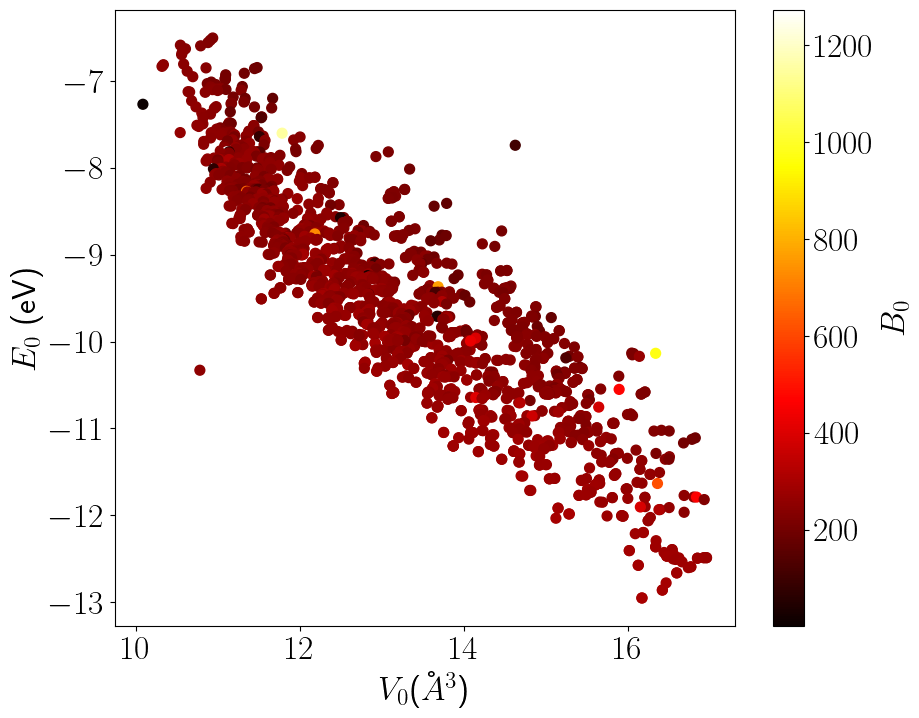

In [17]:
#fig, ax = plt.subplots()
plt.scatter(BS.V0, BS.E0, c=BS.B0, marker = 'o' , s = 50, cmap='hot')
cbar = plt.colorbar()
plt.ylabel(targets['E0']+' (eV)')
plt.xlabel(targets['V0']+'($\AA^3$)')
cbar.set_label(targets['B0'])

In [18]:
list(targets.items())[:2]

[('E0', '$E_0$'), ('B0', '$B_0$')]

from the plots below, we only would put in the paper the one with _V_0 in x, E_0 in y and B_0 in color coding_

# Pair Plots

In [19]:
ToPlot = BS[list(targets.keys())] #+['Phase']]
ToPlot.columns = list(targets.values()) #+['Phase']

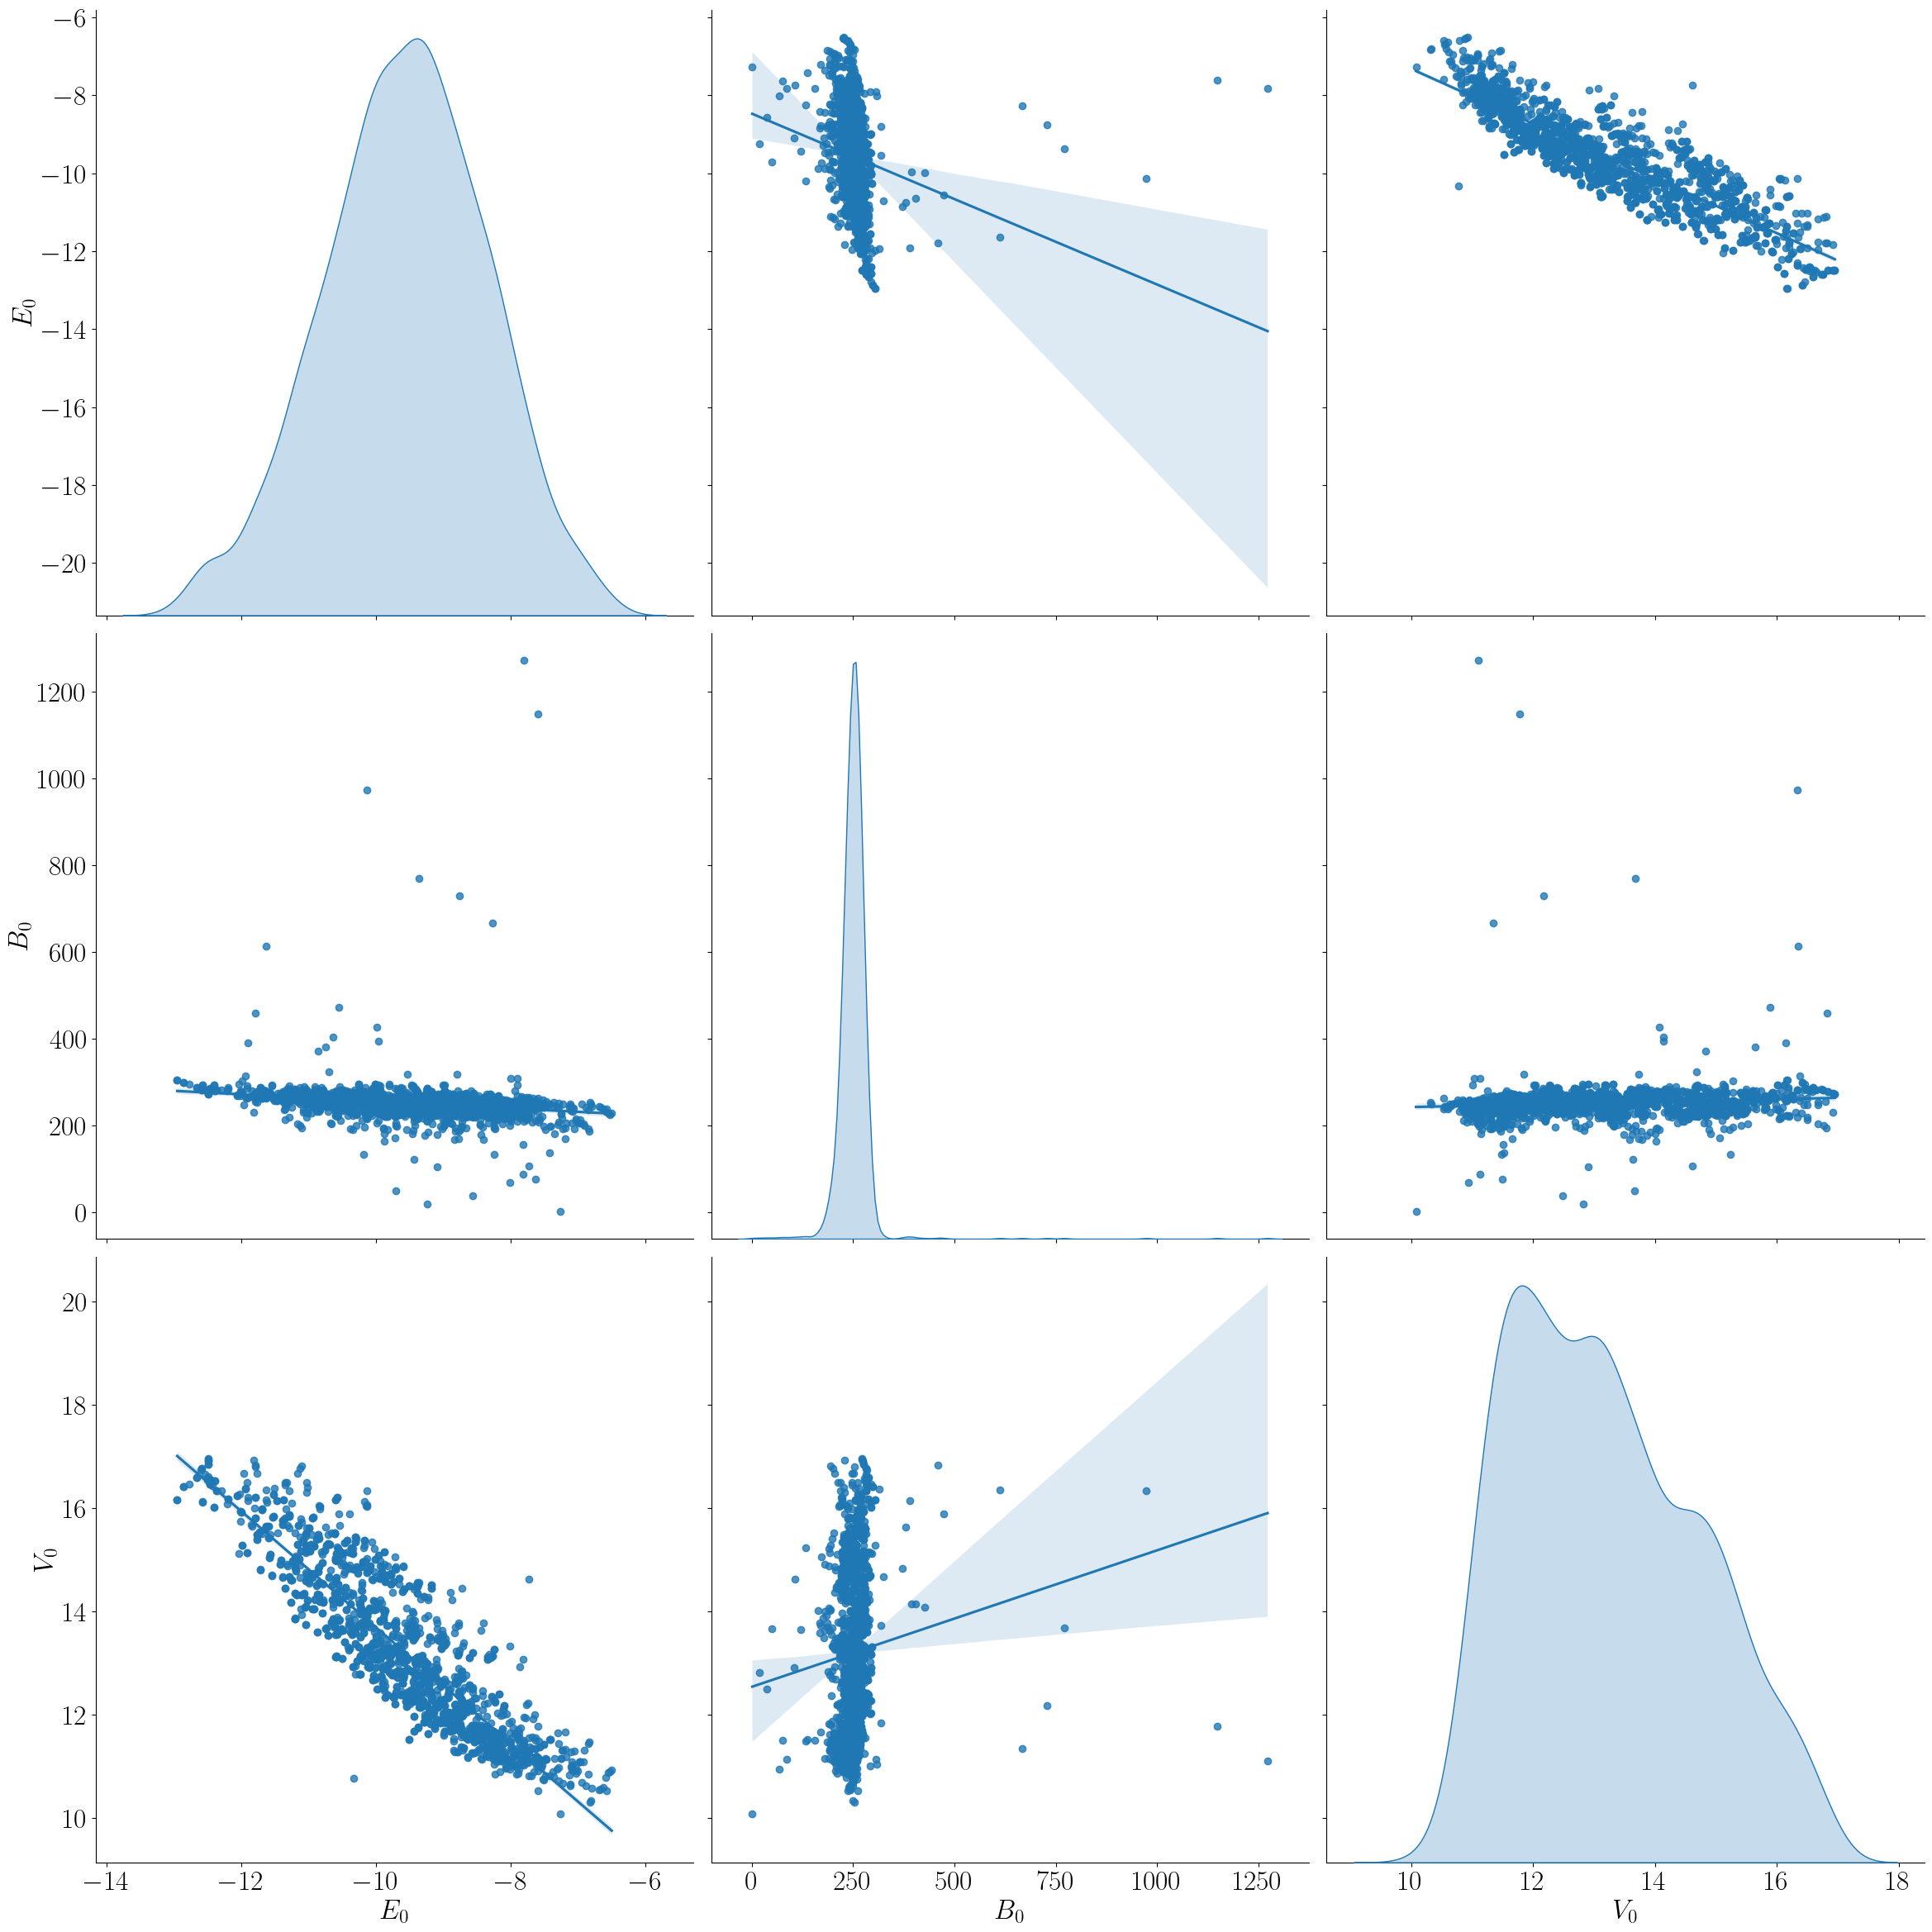

In [20]:
axis_grid = sns.pairplot(ToPlot, diag_kind = 'kde', kind='reg', height=8)
#, hue='Phase', x_vars=list(targets.values()), y_vars=list(targets.values()), )

# convex hulls ?

In [21]:
import pandas as pd
from scipy.spatial import ConvexHull

In [22]:
PhaseBS = {}
verts = {}

for phase in BS.Phase.unique():
    PhaseBS[phase] = BS[BS.Phase == phase]

In [13]:
for phase, bs in PhaseBS.items():
    if bs.shape[0] <= 1:
        continue  # cant make CH with less than 1 sample
    chull = ConvexHull(bs[['Fe_pv','EF']])
    verts[phase] = chull.vertices

KeyError: "['Fe_pv'] not in index"

In [23]:
irrelevant = ['sigma', 'chi', 'hcp','A15','C15' ,'fcc']

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


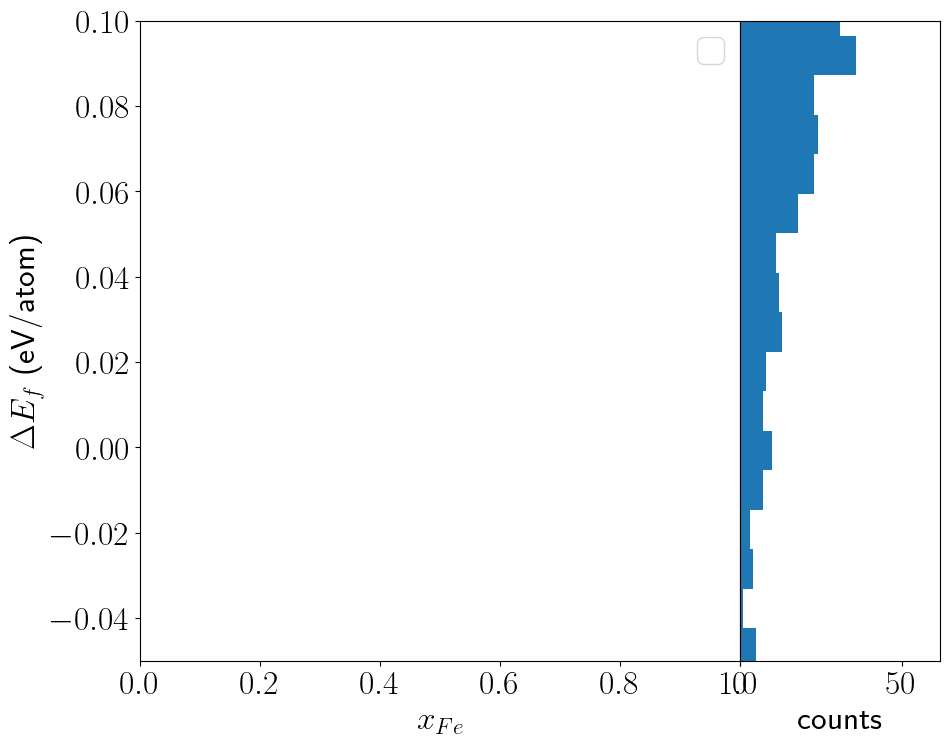

In [24]:
fig = plt.figure()
ax = fig.add_axes([0.2,0.2,0.6,0.8])
for phase, vertices in verts.items():
    if phase not in irrelevant:
    #    plt.plot(bs['Fe_pv'], bs['EF'], 'o')
        ax.plot(PhaseBS[phase]['Fe_pv'][vertices], PhaseBS[phase]['EF'][vertices], label=phase)
ax.set_ylim([-0.05, 0.1])
ax2 = fig.add_axes([0.8, 0.2, 0.2, 0.8], sharey=ax)
ax2.hist(BS['EF'], bins=100, orientation='horizontal')
ax2.set_xlabel('counts')
ax2.yaxis.set_visible(False)
ax.set_xlabel('$x_{Fe}$')
ax.set_ylabel('$\Delta E_f$ (eV/atom)')
ax.legend()

In [25]:
BS.to_pickle(os.path.join(dataset, f'CuratedParsedBriefSummary.pkl'))